#**Machine Learning-Based Revenue Forecasting** and Onboarding Patterns Across Multi-Country Payment Networks: **A Case Study of Arab Financial Services**

#**Bahrain AFS (Arab Financial Services) Forcast Revenue**

#SECTION 1 — Setup: Google Drive + Libraries

In [1]:
# --- Mount Google Drive ---
from google.colab import drive
drive.mount('/content/drive')

# --- Core libraries ---
import pandas as pd
import numpy as np

# --- Feature Engineering ---
!pip install holidays -q
import holidays
!pip install hijridate -q
from hijridate import Gregorian

# --- Visualisation ---
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

# --- Modelling ---
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
import xgboost as xgb
!pip install lightgbm catboost pmdarima -q
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

# --- Display settings ---
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
plt.rcParams['figure.figsize'] = (14, 5)
sns.set_style('whitegrid')

# --- File path ---
FILE_PATH = '/content/drive/MyDrive/Colab Notebooks/Thesis/Thesis_Datasets/BH_AFS_daily_revenue_dataset.xlsx'

print('Setup complete.')
print('Libraries loaded: pandas, numpy, matplotlib, seaborn, sklearn, xgboost')

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 38.8 MB/s eta 0:00:00
Setup complete.
Libraries loaded: pandas, numpy, matplotlib, seaborn, sklearn, xgboost


#SECTION 2 — Data Structure

In [2]:
df_raw = pd.read_excel(FILE_PATH)
df_raw['Settlement Date'] = pd.to_datetime(df_raw['Settlement Date'])

# ---------- 2.1 Structure ----------
print('=' * 70)
print('2.1  DATA STRUCTURE')
print('=' * 70)
print(f'Shape       : {df_raw.shape[0]:,} rows  x  {df_raw.shape[1]} columns')
print(f'Date range  : {df_raw["Settlement Date"].min().date()}  ->  {df_raw["Settlement Date"].max().date()}')
print(f'Memory      : {df_raw.memory_usage(deep=True).sum()/1024:.1f} KB')
print()
print(df_raw.dtypes.to_frame('dtype').to_string())
print()
display(df_raw.head())

# ---------- 2.2 Data quality: nulls, duplicates, zeros ----------
print('=' * 70)
print('2.2  DATA QUALITY')
print('=' * 70)

quality = pd.DataFrame({
    'dtype'  : df_raw.dtypes.astype(str),
    'nulls'  : df_raw.isna().sum(),
    'null_%' : (df_raw.isna().sum() / len(df_raw) * 100).round(2),
    'zeros'  : (df_raw == 0).sum(),
    'unique' : df_raw.nunique(),
})
display(quality)

print(f'Duplicate full rows       : {df_raw.duplicated().sum()}')
print(f'Duplicate Settlement Dates: {df_raw["Settlement Date"].duplicated().sum()}')

full_range   = pd.date_range(df_raw['Settlement Date'].min(),
                             df_raw['Settlement Date'].max(), freq='D')
missing_days = full_range.difference(df_raw['Settlement Date'])
print(f'Missing calendar days     : {len(missing_days)}')
if 0 < len(missing_days) <= 10:
    print(f'   -> {list(missing_days.date)}')
print()

# ---------- 2.3 Statistical summary ----------
print('=' * 70)
print('2.3  STATISTICAL SUMMARY')
print('=' * 70)
num_cols = ['Transaction Count', 'Transaction Amount',
            'Average Transaction Amount', 'Profit']
stats = df_raw[num_cols].describe().T
stats['skew'] = df_raw[num_cols].skew()
display(stats.round(2))

# ---------- 2.4 Yearly consistency (margin check) ----------
print('=' * 70)
print('2.4  YEARLY BREAKDOWN — margin consistency check')
print('=' * 70)
yr = df_raw.groupby(df_raw['Settlement Date'].dt.year).agg(
    days             = ('Profit', 'size'),
    txn_count        = ('Transaction Count', 'sum'),
    amount           = ('Transaction Amount', 'sum'),
    profit           = ('Profit', 'sum'),
    avg_daily_profit = ('Profit', 'mean'),
)
yr['margin_%'] = (yr['profit'] / yr['amount'] * 100).round(2)
display(yr.round(0))

2.1  DATA STRUCTURE
Shape       : 1,290 rows  x  11 columns
Date range  : 2023-01-01  ->  2026-07-01
Memory      : 293.7 KB

                                     dtype
Country                             object
Source                              object
Currency                            object
Transaction Count                    int64
Transaction Amount                 float64
Average Transaction Amount         float64
Profit                             float64
Settlement Year                      int64
Settlement Month                     int64
Settlement Date             datetime64[ns]
Settlement Day                       int64



,Country,Source,Currency,Transaction Count,Transaction Amount,Average Transaction Amount,Profit,Settlement Year,Settlement Month,Settlement Date,Settlement Day
0,Bahrain,AFSPOSTILION,BHD,141029,"2,102,723.06",16.96,"57,317.40",2023,1,2023-01-01,0
1,Bahrain,AFSPOSTILION,BHD,121832,"1,402,401.80",13.61,"38,783.06",2023,1,2023-01-02,1
2,Bahrain,AFSPOSTILION,BHD,99318,"1,190,378.94",13.68,"32,246.48",2023,1,2023-01-03,2
3,Bahrain,AFSPOSTILION,BHD,104195,"1,226,700.98",29.30,"33,243.76",2023,1,2023-01-04,3
4,Bahrain,AFSPOSTILION,BHD,103917,"1,108,928.89",14.53,"30,094.62",2023,1,2023-01-05,4


2.2  DATA QUALITY


,dtype,nulls,null_%,zeros,unique
Country,object,0,0.00,0,1
Source,object,0,0.00,0,1
Currency,object,0,0.00,0,1
Transaction Count,int64,0,0.00,0,1281
Transaction Amount,float64,0,0.00,3,1288
Average Transaction Amount,float64,0,0.00,0,1290
Profit,float64,0,0.00,3,1288
Settlement Year,int64,0,0.00,0,4
Settlement Month,int64,0,0.00,0,12
Settlement Date,datetime64[ns],0,0.00,0,1278


Duplicate full rows       : 0
Duplicate Settlement Dates: 12
Missing calendar days     : 0

2.3  STATISTICAL SUMMARY


,count,mean,std,min,25%,50%,75%,max,skew
Transaction Count,"1,290.00","184,367.79","57,825.01",1.00,"136,007.00","187,524.00","225,813.50","361,433.00",-0.06
Transaction Amount,"1,290.00","2,195,097.04","889,262.12",0.00,"1,678,060.07","2,200,675.09","2,598,872.07","14,858,125.63",6.12
Average Transaction Amount,"1,290.00",17.62,48.78,-22.00,12.24,13.71,15.77,"1,511.16",25.02
Profit,"1,290.00","61,164.59","29,082.32",0.00,"46,047.67","60,777.92","72,220.69","523,684.26",8.33


2.4  YEARLY BREAKDOWN — margin consistency check


,days,txn_count,amount,profit,avg_daily_profit,margin_%
Settlement Date,,,,,,
2023,365,44614570,"558,867,895.00","15,377,075.00","42,129.00",3.00
2024,366,66032260,"812,123,486.00","22,150,616.00","60,521.00",3.00
2025,377,84760581,"995,259,444.00","28,415,727.00","75,373.00",3.00
2026,182,42427039,"465,424,350.00","12,958,900.00","71,203.00",3.00


#SECTION 3 — Cleaning

In [3]:
df = df_raw.copy()
df.columns = df.columns.str.strip()

# ---------- 3.1 Drop constant metadata columns ----------
df = df.drop(columns=['Country', 'Source', 'Currency'], errors='ignore')

# ---------- 3.2 Resolve duplicate dates (sum the additive metrics) ----------
n_dups = df['Settlement Date'].duplicated().sum()
df = (df.groupby('Settlement Date', as_index=False)
        .agg({'Transaction Count' : 'sum',
              'Transaction Amount': 'sum',
              'Profit'            : 'sum'}))

# ---------- 3.3 Fill missing calendar days with that MONTH's average ----------
df = df.sort_values('Settlement Date').reset_index(drop=True)

full_range   = pd.date_range(df['Settlement Date'].min(),
                             df['Settlement Date'].max(), freq='D')
missing_days = full_range.difference(df['Settlement Date'])

if len(missing_days) > 0:
    df['_ym']  = df['Settlement Date'].dt.to_period('M')
    month_avg  = df.groupby('_ym')[['Transaction Count',
                                    'Transaction Amount',
                                    'Profit']].mean()

    fills = []
    for d in missing_days:
        ym   = pd.Period(d, freq='M')
        vals = month_avg.loc[ym] if ym in month_avg.index else \
               df[['Transaction Count','Transaction Amount','Profit']].mean()
        fills.append({'Settlement Date'   : d,
                      'Transaction Count' : vals['Transaction Count'],
                      'Transaction Amount': vals['Transaction Amount'],
                      'Profit'            : vals['Profit']})

    df = df.drop(columns='_ym')
    df = pd.concat([df, pd.DataFrame(fills)], ignore_index=True)
    df = df.sort_values('Settlement Date').reset_index(drop=True)

# ---------- 3.4 Recompute Average Transaction Amount ----------
df['Average Transaction Amount'] = (
    df['Transaction Amount'] / df['Transaction Count']
).replace([np.inf, -np.inf], np.nan)

# ---------- 3.5 Rebuild calendar columns ----------
df['Settlement Year']  = df['Settlement Date'].dt.year
df['Settlement Month'] = df['Settlement Date'].dt.month
df['Settlement Day']   = df['Settlement Date'].dt.dayofweek   # 0=Mon ... 6=Sun

# ---------- 3.6 Verification ----------
final_range   = pd.date_range(df['Settlement Date'].min(),
                              df['Settlement Date'].max(), freq='D')
still_missing = final_range.difference(df['Settlement Date'])

print('=' * 70)
print('CLEANING VERIFICATION')
print('=' * 70)
print(f'Rows            : {len(df_raw):,}  ->  {len(df):,}')
print(f'Duplicate dates : {n_dups}  ->  {df["Settlement Date"].duplicated().sum()}')
print(f'Missing days    : {len(missing_days)}  ->  {len(still_missing)} ')
if len(missing_days):
    print(f'   filled       : {list(missing_days.date)}')
print(f'Profit zeros    : {(df["Profit"] == 0).sum()}')
print(f'Nulls remaining : {df.isna().sum().sum()}')
print()
print(f'Avg Txn Amount  : min {df["Average Transaction Amount"].min():.2f}  '
      f'max {df["Average Transaction Amount"].max():.2f}  '
      f'median {df["Average Transaction Amount"].median():.2f}')
print(f'Columns: {list(df.columns)}')
display(df.head())

CLEANING VERIFICATION
Rows            : 1,290  ->  1,278
Duplicate dates : 12  ->  0
Missing days    : 0  ->  0 
Profit zeros    : 0
Nulls remaining : 0

Avg Txn Amount  : min 8.45  max 100.86  median 11.82
Columns: ['Settlement Date', 'Transaction Count', 'Transaction Amount', 'Profit', 'Average Transaction Amount', 'Settlement Year', 'Settlement Month', 'Settlement Day']


,Settlement Date,Transaction Count,Transaction Amount,Profit,Average Transaction Amount,Settlement Year,Settlement Month,Settlement Day
0,2023-01-01,141029,"2,102,723.06","57,317.40",14.91,2023,1,6
1,2023-01-02,121832,"1,402,401.80","38,783.06",11.51,2023,1,0
2,2023-01-03,99318,"1,190,378.94","32,246.48",11.99,2023,1,1
3,2023-01-04,104195,"1,226,700.98","33,243.76",11.77,2023,1,2
4,2023-01-05,103917,"1,108,928.89","30,094.62",10.67,2023,1,3


#SECTION 5 — Feature Engineering

In [4]:
# ---------- 5.1 is_weekend (Bahrain: Friday=4, Saturday=5) ----------
df['is_weekend'] = df['Settlement Date'].dt.dayofweek.isin([4, 5]).astype(int)

# ---------- 5.2 is_holiday (Bahrain public holidays) ----------
bh_holidays = holidays.Bahrain(years=[2023, 2024, 2025, 2026])
df['is_holiday'] = df['Settlement Date'].dt.date.isin(bh_holidays).astype(int)
print(f'Holiday days flagged: {df["is_holiday"].sum()}')

# ---------- 5.3 Lag & rolling features ----------
df['lag_1']           = df['Profit'].shift(1)                        # yesterday's profit
df['avg_tran_lag1'] = df['Average Transaction Amount'].shift(1)    # yesterday's avg ticket size
df['roll7_mean']      = df['Profit'].rolling(7).mean().shift(1)      # last 7-day avg profit
df['lag_28']          = df['Profit'].shift(28)                       # four weeks back (monthly cycle)
df['lag_amount1']           = df['Transaction Amount'].shift(1)
df['lag_count1']           = df['Transaction Count'].shift(1)
df['lag_amount2']           = df['Transaction Amount'].shift(7)
df['lag_count2']           = df['Transaction Count'].shift(7)
df['roll7_std']      = df['Profit'].shift(1).rolling(7).std()

# ---------- 5.4 Islamic-calendar (Hijri) features ----------
# Ramadan spending drops ~26.5%; it shifts ~11 days earlier each Gregorian year,
# so Settlement Month cannot capture it — a Hijri flag is required.
def _hijri(dt):
    h = Gregorian(dt.year, dt.month, dt.day).to_hijri()
    return pd.Series({'hijri_month': h.month, 'hijri_day': h.day})

_h = df['Settlement Date'].apply(_hijri)
df['hijri_month'] = _h['hijri_month']
df['hijri_day']   = _h['hijri_day']

df['is_ramadan']     = (df['hijri_month'] == 9).astype(int)                        # month 9 = Ramadan
df['ramadan_last10'] = ((df['hijri_month'] == 9) & (df['hijri_day'] >= 20)).astype(int)  # pre-Eid peak

print(f'Ramadan days flagged   : {df["is_ramadan"].sum()}')

# drop the raw hijri_month/day — they HURT as ordinal features (cyclical); keep only the flags
df = df.drop(columns=['hijri_month', 'hijri_day'])

# ---------- 5.5 FINAL DATASET ----------
print('=' * 70)
print('FINAL DATASET')
print('=' * 70)
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}')
print()
print('--- First 10 rows ---')
display(df.head(10))

# ---------- 5.6 Ramadan effect check (nice for the thesis) ----------
print('\nRamadan effect on profit:')
r = df[df['is_ramadan']==1]['Profit'].mean()
n = df[df['is_ramadan']==0]['Profit'].mean()
print(f'  Ramadan    : {r:,.0f} BHD/day')
print(f'  Non-Ramadan: {n:,.0f} BHD/day')
print(f'  Effect     : {(r/n-1)*100:+.1f}%')

Holiday days flagged: 53
Ramadan days flagged   : 118
FINAL DATASET
Shape: 1,278 rows x 21 columns
Columns: ['Settlement Date', 'Transaction Count', 'Transaction Amount', 'Profit', 'Average Transaction Amount', 'Settlement Year', 'Settlement Month', 'Settlement Day', 'is_weekend', 'is_holiday', 'lag_1', 'avg_tran_lag1', 'roll7_mean', 'lag_28', 'lag_amount1', 'lag_count1', 'lag_amount2', 'lag_count2', 'roll7_std', 'is_ramadan', 'ramadan_last10']

--- First 10 rows ---


,Settlement Date,Transaction Count,Transaction Amount,Profit,Average Transaction Amount,Settlement Year,Settlement Month,Settlement Day,is_weekend,is_holiday,lag_1,avg_tran_lag1,roll7_mean,lag_28,lag_amount1,lag_count1,lag_amount2,lag_count2,roll7_std,is_ramadan,ramadan_last10
0,2023-01-01,141029,"2,102,723.06","57,317.40",14.91,2023,1,6,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
1,2023-01-02,121832,"1,402,401.80","38,783.06",11.51,2023,1,0,0,0,"57,317.40",14.91,NaN,NaN,"2,102,723.06","141,029.00",NaN,NaN,NaN,0,0
2,2023-01-03,99318,"1,190,378.94","32,246.48",11.99,2023,1,1,0,0,"38,783.06",11.51,NaN,NaN,"1,402,401.80","121,832.00",NaN,NaN,NaN,0,0
3,2023-01-04,104195,"1,226,700.98","33,243.76",11.77,2023,1,2,0,0,"32,246.48",11.99,NaN,NaN,"1,190,378.94","99,318.00",NaN,NaN,NaN,0,0
4,2023-01-05,103917,"1,108,928.89","30,094.62",10.67,2023,1,3,0,0,"33,243.76",11.77,NaN,NaN,"1,226,700.98","104,195.00",NaN,NaN,NaN,0,0
5,2023-01-06,101781,"1,161,253.16","31,703.83",11.41,2023,1,4,1,0,"30,094.62",10.67,NaN,NaN,"1,108,928.89","103,917.00",NaN,NaN,NaN,0,0
6,2023-01-07,104714,"1,130,698.12","30,810.50",10.80,2023,1,5,1,0,"31,703.83",11.41,NaN,NaN,"1,161,253.16","101,781.00",NaN,NaN,NaN,0,0
7,2023-01-08,113607,"1,362,120.10","37,686.63",11.99,2023,1,6,0,0,"30,810.50",10.80,"36,314.24",NaN,"1,130,698.12","104,714.00","2,102,723.06","141,029.00","9,690.49",0,0
8,2023-01-09,98421,"1,127,805.32","30,591.15",11.46,2023,1,0,0,0,"37,686.63",11.99,"33,509.84",NaN,"1,362,120.10","113,607.00","1,402,401.80","121,832.00","3,394.39",0,0
9,2023-01-10,100024,"1,074,027.21","29,022.16",10.74,2023,1,1,0,0,"30,591.15",11.46,"32,339.57",NaN,"1,127,805.32","98,421.00","1,190,378.94","99,318.00","2,590.25",0,0



Ramadan effect on profit:
  Ramadan    : 46,526 BHD/day
  Non-Ramadan: 63,286 BHD/day
  Effect     : -26.5%


#SECTION 7: Model Training & Evaluation

In [8]:
from sklearn.linear_model import LinearRegression
FEATURES = ['Settlement Year', 'Settlement Month', 'Settlement Day',
            'is_weekend', 'is_holiday',
            'lag_1','avg_tran_lag1','roll7_mean', 'lag_28','is_ramadan', 'ramadan_last10'#,'lag_amount1','lag_amount2','lag_count1','lag_count2','roll7_std'
            ]
TARGET = 'Profit'
SPLIT  = '2026-01-01'

def evaluate(y, p):
    ape = np.abs((y - p) / y) * 100
    return {'MAPE%' : ape.mean(),
            'MAE'   : mean_absolute_error(y, p),
            'RMSE'  : np.sqrt(mean_squared_error(y, p))#,
            #'R2'    : r2_score(y, p)
        }
# ---------- split (once — FEATURES is a single list) ----------
d  = df.dropna(subset=FEATURES + [TARGET]).copy()
tr = d[d['Settlement Date'] <  SPLIT]
te = d[d['Settlement Date'] >= SPLIT]

X_tr, y_tr = tr[FEATURES], tr[TARGET]
X_te, y_te = te[FEATURES], te[TARGET]

print(f'TRAIN: {len(tr):,} rows | {tr["Settlement Date"].min().date()} -> {tr["Settlement Date"].max().date()}')
print(f'TEST : {len(te):,} rows | {te["Settlement Date"].min().date()} -> {te["Settlement Date"].max().date()}')
print()

# ---------- BASELINE ----------
baselines = {
    'Linear Regression': LinearRegression(),
}
# ---------- PROPOSED MODELS ----------
models = {
    'Random Forest'     : RandomForestRegressor(n_estimators=1000,
                                                random_state=42, n_jobs=-1),

    'Gradient Boosting' : GradientBoostingRegressor(n_estimators=1000, learning_rate=0.01,
                                                    max_depth=6, subsample=0.8,
                                                    random_state=42),

    'XGBoost'           : xgb.XGBRegressor(n_estimators=1000, learning_rate=0.01,
                                           max_depth=6, random_state=42, n_jobs=-1),

}

rows = []

for mname, model in baselines.items():
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    rows.append({'Type': 'Baseline', 'Model': mname, **evaluate(y_te.values, pred)})

for mname, model in models.items():
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    rows.append({'Type': 'Proposed', 'Model': mname, **evaluate(y_te.values, pred)})

results = pd.DataFrame(rows)

print('Bahrain Arab Financial Services (AFS) MODEL COMPARISON (2026 test set)')
display(results.round(2))

TRAIN: 1,068 rows | 2023-01-29 -> 2025-12-31
TEST : 182 rows | 2026-01-01 -> 2026-07-01

Bahrain Arab Financial Services (AFS) MODEL COMPARISON (2026 test set)


,Type,Model,MAPE%,MAE,RMSE
0,Baseline,Linear Regression,11.90,"7,550.05","9,677.66"
1,Proposed,Random Forest,9.77,"6,595.62","8,888.38"
2,Proposed,Gradient Boosting,9.26,"6,347.86","8,699.46"
3,Proposed,XGBoost,8.46,"5,664.87","7,793.65"


#Check Overfitting/Underfitting

In [6]:
def mape(y, p):
    return np.mean(np.abs((y - p) / y)) * 100

# ---- collect train vs test scores for each model ----
names, tr_mape, te_mape, tr_rmse, te_rmse = [], [], [], [], []

for mname, model in {**baselines, **models}.items():
    model.fit(X_tr, y_tr)
    names.append(mname)
    tr_mape.append(mape(y_tr.values, model.predict(X_tr)))
    te_mape.append(mape(y_te.values, model.predict(X_te)))
    tr_rmse.append(np.sqrt(mean_squared_error(y_tr, model.predict(X_tr))))
    te_rmse.append(np.sqrt(mean_squared_error(y_te, model.predict(X_te))))

# ---- print the gap table ----
print(f'{"Model":<20}{"Train MAPE":>11}{"Test MAPE":>11}{"Gap":>8}')
print('-' * 50)
for i in range(len(names)):
    print(f'{names[i]:<20}{tr_mape[i]:>10.2f}%{te_mape[i]:>10.2f}%{te_mape[i]-tr_mape[i]:>7.1f}')

Model                Train MAPE  Test MAPE     Gap
--------------------------------------------------
Linear Regression         9.67%     11.90%    2.2
Random Forest             4.03%      9.77%    5.7
Gradient Boosting         3.01%      9.26%    6.3
XGBoost                   3.93%      8.46%    4.5


#SECTION 7: Prediction (Remaining of 2026)

In [ ]:
# ============================================================
# RECURSIVE FORECAST — from end of data to 31 Dec 2026
# ============================================================
FEATURES = ['Settlement Year','Settlement Month','Settlement Day',
            'is_weekend','is_holiday',
            'lag_1','avg_tran_lag1','roll7_mean','lag_28',
            'is_ramadan','ramadan_last10']

BH = holidays.Bahrain(years=[2023,2024,2025,2026])

def hijri_md(dt):
    h = Gregorian(dt.year, dt.month, dt.day).to_hijri()
    return h.month, h.day

last_date    = df['Settlement Date'].max()
future_dates = pd.date_range(last_date + pd.Timedelta(days=1), '2026-12-31', freq='D')

profit_hist = list(df['Profit'].values)
# yesterday's avg transaction amount — held at the recent 28-day average across the horizon
avg_tran    = df['Average Transaction Amount'].tail(28).mean()

future_rows = []
for dt in future_dates:
    hm, hd = hijri_md(dt)
    feat = {
        'Settlement Year' : dt.year,
        'Settlement Month': dt.month,
        'Settlement Day'  : dt.dayofweek,
        'is_weekend'      : int(dt.dayofweek in [4, 5]),
        'is_holiday'      : int(dt.date() in BH),
        'lag_1'           : profit_hist[-1],
        'avg_tran_lag1'   : avg_tran,              # ← matches your column name
        'roll7_mean'      : np.mean(profit_hist[-7:]),
        'lag_28'          : profit_hist[-28],
        'is_ramadan'      : int(hm == 9),
        'ramadan_last10'  : int(hm == 9 and hd >= 20),
    }
    yhat = float(model.predict(pd.DataFrame([feat])[FEATURES])[0])
    profit_hist.append(yhat)
    future_rows.append({'Settlement Date': dt, 'Predicted': yhat})

future = pd.DataFrame(future_rows)

print(f'Forecast: {future["Settlement Date"].min().date()} -> {future["Settlement Date"].max().date()}')
print(f'Days forecast     : {len(future)}')
print(f'Jul-Dec 2026 total: {future["Predicted"].sum():,.0f} BHD')
print(f'Daily mean        : {future["Predicted"].mean():,.0f} BHD')

# ---- combined table: actuals + forecast ----
actual = df[['Settlement Date','Profit']].rename(columns={'Profit':'Actual'})
actual['Predicted'] = np.nan
actual['Type']      = 'Actual'

fc = future.copy()
fc['Actual'] = np.nan
fc['Type']   = 'Forecast'

combined = pd.concat([actual[['Settlement Date','Actual','Predicted','Type']],
                      fc[['Settlement Date','Actual','Predicted','Type']]],
                     ignore_index=True).sort_values('Settlement Date').reset_index(drop=True)

combined['Profit_Best']       = combined['Actual'].fillna(combined['Predicted'])
combined['Cumulative Profit'] = combined.groupby(combined['Settlement Date'].dt.year)['Profit_Best'].cumsum()

combined.to_csv('BH_AFS_forecast_2026.csv', index=False)

Forecast: 2026-07-02 -> 2026-12-31
Days forecast     : 183
Jul-Dec 2026 total: 13,913,405 BHD
Daily mean        : 76,030 BHD


#Visualization

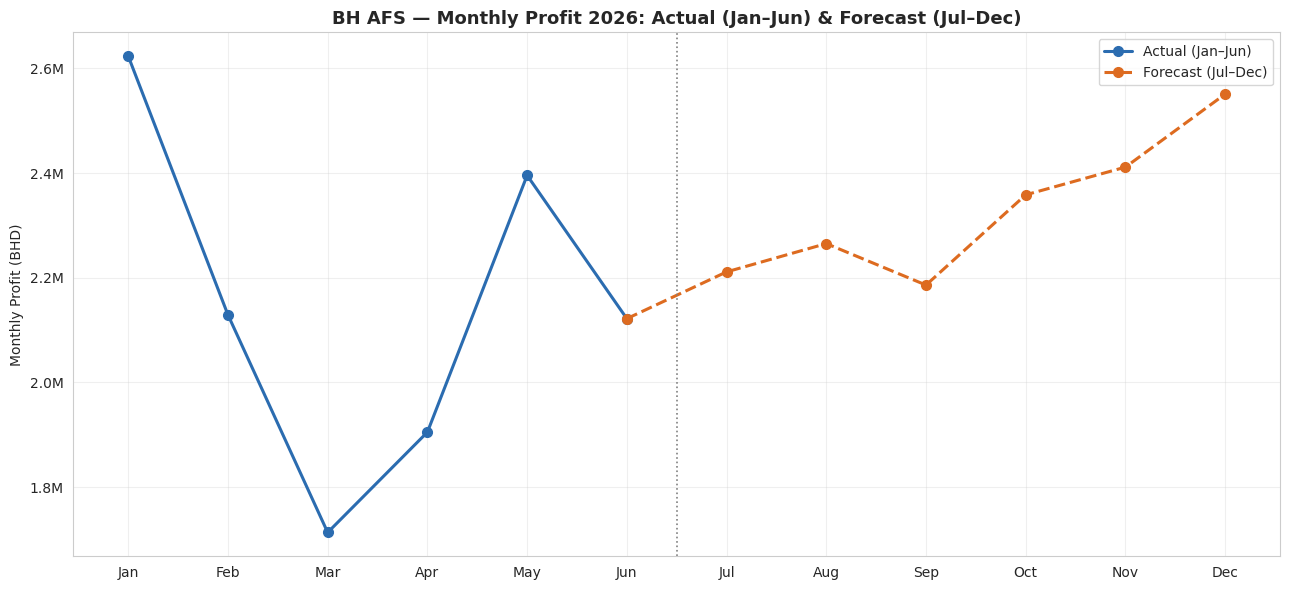

MONTHLY 2026 (BHD):
  Jan:    2,623,509  [Actual]
  Feb:    2,129,111  [Actual]
  Mar:    1,713,346  [Actual]
  Apr:    1,905,067  [Actual]
  May:    2,395,688  [Actual]
  Jun:    2,121,933  [Actual]
  Jul:    2,211,252  [Forecast]
  Aug:    2,265,323  [Forecast]
  Sep:    2,186,097  [Forecast]
  Oct:    2,358,512  [Forecast]
  Nov:    2,411,474  [Forecast]
  Dec:    2,550,993  [Forecast]

Total 2026: 26,872,305 BHD


In [ ]:
# ---- combine 2026 daily actual + forecast, aggregate to MONTHLY ----
a = df[df['Settlement Date'].dt.year == 2026][['Settlement Date','Profit']].rename(columns={'Profit':'val'})
f = future.rename(columns={'Predicted':'val'})[['Settlement Date','val']]

alld = pd.concat([a, f], ignore_index=True).sort_values('Settlement Date')
alld['month'] = alld['Settlement Date'].dt.month
monthly = alld.groupby('month')['val'].sum()

names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
vals  = monthly.reindex(range(1,13)).values

# split: Jan-Jun actual, Jul-Dec forecast (overlap at Jun so the lines connect)
act_x, act_y = list(range(6)),   vals[:6]
fc_x,  fc_y  = list(range(5,12)), vals[5:]

plt.figure(figsize=(13,6))
plt.plot(act_x, act_y, 'o-',  color='#2B6CB0', lw=2.2, markersize=7, label='Actual (Jan–Jun)')
plt.plot(fc_x,  fc_y,  'o--', color='#DD6B20', lw=2.2, markersize=7, label='Forecast (Jul–Dec)')
plt.axvline(5.5, color='gray', ls=':', lw=1.2)

plt.xticks(range(12), names)
plt.ylabel('Monthly Profit (BHD)')
plt.title('BH AFS — Monthly Profit 2026: Actual (Jan–Jun) & Forecast (Jul–Dec)',
          weight='bold', fontsize=13)
plt.legend(); plt.grid(alpha=0.3)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.tight_layout()
plt.show()

# ---- print the monthly table ----
print('MONTHLY 2026 (BHD):')
for i, v in enumerate(vals):
    kind = 'Actual' if i < 6 else 'Forecast'
    print(f'  {names[i]}: {v:>12,.0f}  [{kind}]')
print(f'\nTotal 2026: {vals.sum():,.0f} BHD')

Train: 1068 days | Test: 182 days | Test MAPE: 8.46%


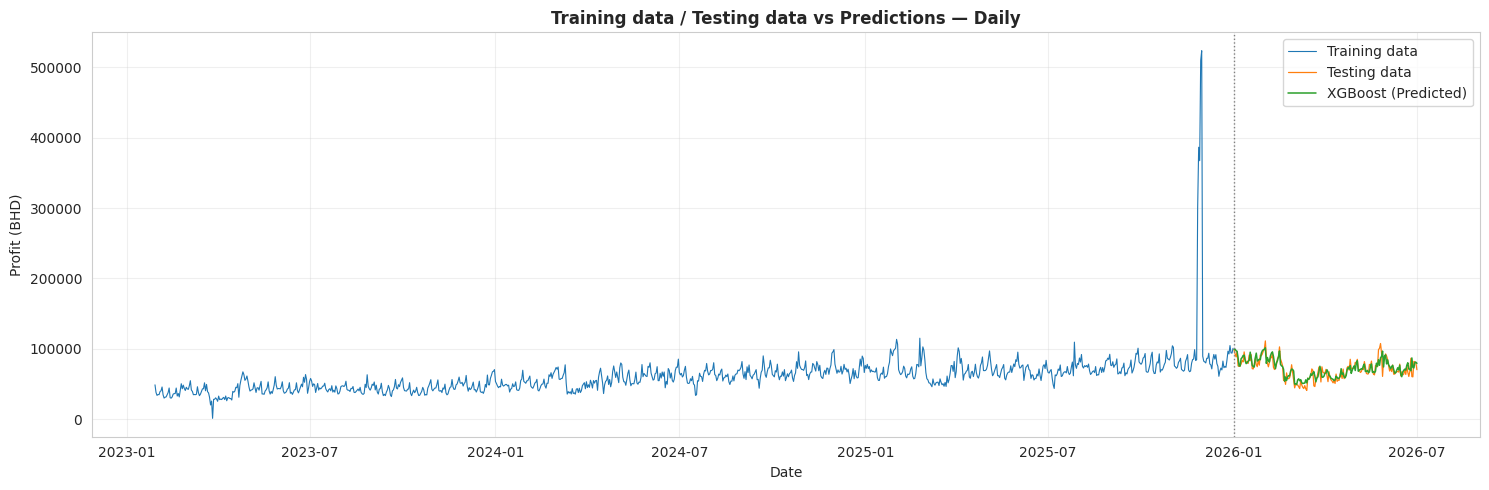

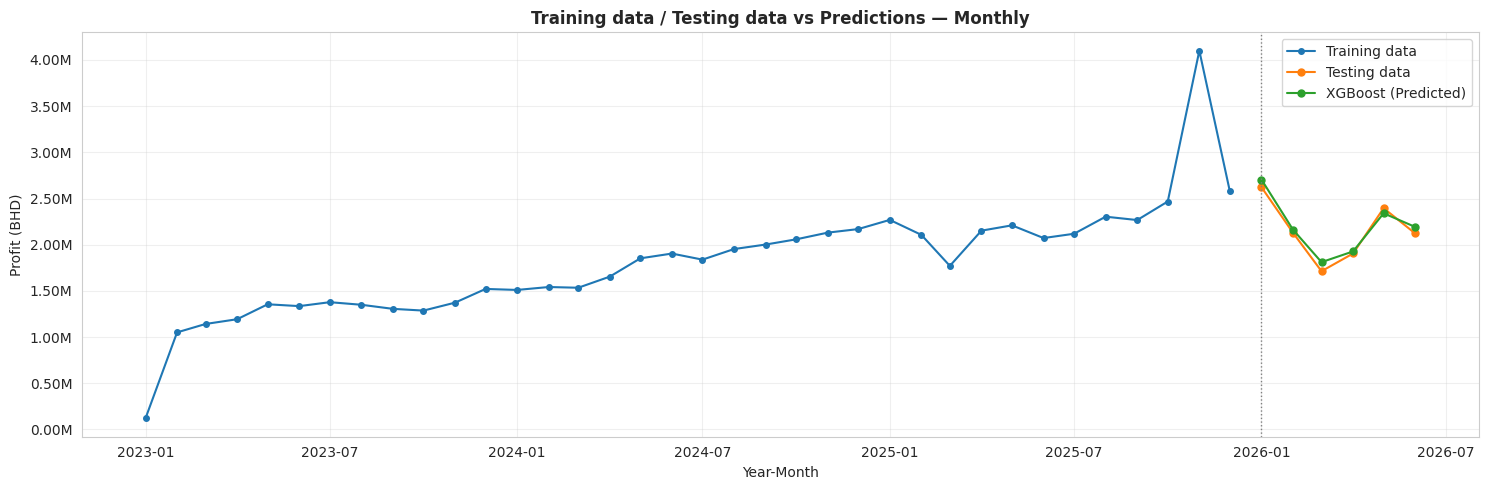

In [ ]:
# ============================================================
# TRAINING / TESTING vs PREDICTIONS — XGBoost
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

SPLIT = '2026-01-01'

# --- Split and predict on the test period ---
d = df.dropna(subset=FEATURES + ['Profit'])
train = d[d['Settlement Date'] <  SPLIT]
test  = d[d['Settlement Date'] >= SPLIT].copy()

test['Predicted'] = model.predict(test[FEATURES])

mape = np.mean(np.abs((test['Profit'] - test['Predicted']) / test['Profit'])) * 100
print(f'Train: {len(train)} days | Test: {len(test)} days | Test MAPE: {mape:.2f}%')

# ---------- DAILY VIEW ----------
plt.figure(figsize=(15, 5))
plt.plot(train['Settlement Date'], train['Profit'],
         color='#1f77b4', lw=0.8, label='Training data')
plt.plot(test['Settlement Date'],  test['Profit'],
         color='#ff7f0e', lw=0.9, label='Testing data')
plt.plot(test['Settlement Date'],  test['Predicted'],
         color='#2ca02c', lw=1.1, label='XGBoost (Predicted)')
plt.axvline(pd.Timestamp(SPLIT), color='gray', ls=':', lw=1)
plt.title('Training data / Testing data vs Predictions — Daily', weight='bold')
plt.xlabel('Date'); plt.ylabel('Profit (BHD)')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ---------- MONTHLY VIEW (closer to your reference chart) ----------
tr_m = train.set_index('Settlement Date')['Profit'].resample('MS').sum()
te_m = test.set_index('Settlement Date')['Profit'].resample('MS').sum()
pr_m = test.set_index('Settlement Date')['Predicted'].resample('MS').sum()

# drop the final partial month (only a few days of data → misleading dip)
last_full = test['Settlement Date'].max().replace(day=1)
if test['Settlement Date'].max().day < 28:
    te_m = te_m[te_m.index < last_full]
    pr_m = pr_m[pr_m.index < last_full]

plt.figure(figsize=(15, 5))
plt.plot(tr_m.index, tr_m.values, 'o-', color='#1f77b4', ms=4, label='Training data')
plt.plot(te_m.index, te_m.values, 'o-', color='#ff7f0e', ms=5, label='Testing data')
plt.plot(pr_m.index, pr_m.values, 'o-', color='#2ca02c', ms=5, label='XGBoost (Predicted)')
plt.axvline(pd.Timestamp(SPLIT), color='gray', ls=':', lw=1)
plt.title('Training data / Testing data vs Predictions — Monthly', weight='bold')
plt.xlabel('Year-Month'); plt.ylabel('Profit (BHD)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.2f}M'))
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()